# Customer Churn Prediction — Iranian Telecom Dataset

This notebook carries out the full process described in `instruct.md` and `PLAN.md`: data cleaning, exploratory analysis, preprocessing, model comparison, threshold selection, risk scoring, feature importance, and business recommendations — end to end, with the reasoning kept next to the code that implements it.

## 1. Setup & raw load

Imports and a first look at the raw file before touching anything.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
plt.rcParams["figure.dpi"] = 100

RAW_PATH = Path("Customer Churn.csv")
DATA_DIR = Path("data")
MODELS_DIR = Path("models")
OUTPUTS_DIR = Path("outputs")
for d in (DATA_DIR, MODELS_DIR, OUTPUTS_DIR):
    d.mkdir(exist_ok=True)

raw = pd.read_csv(RAW_PATH)
print("Shape:", raw.shape)
raw.head()

Shape: (3150, 14)


,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
0,8,0,38,0,4370,71,5,17,3,1,1,30,197.640,0
1,0,0,39,0,318,5,7,4,2,1,2,25,46.035,0
2,10,0,37,0,2453,60,359,24,3,1,1,30,1536.520,0
3,10,0,38,0,4198,66,1,35,1,1,1,15,240.020,0
4,3,0,38,0,2393,58,2,33,1,1,1,15,145.805,0


## 2. Data cleaning

Findings from the initial exploration that drive the cleaning decisions below:

- **300 exact duplicate rows** (~9.5% of the data) — dropped outright, they add no information and would bias training.
- **`Age` is redundant** — every row's `Age` is fully determined by `Age Group` (1→15, 2→25, 3→30, 4→45, 5→55). It's a bucket label dressed up as a number, not a real age. We keep `Age Group` (honestly ordinal) and drop `Age`.
- **Column names have inconsistent double spaces** (`'Call  Failure'`, `'Subscription  Length'`, `'Charge  Amount'`) — normalized to clean snake_case.
- **132 customers (4.2%) are fully dormant**: zero `Seconds of Use`, zero `Frequency of use`, zero `Frequency of SMS`, and `Customer Value` = 0. We don't drop them — a `is_dormant` flag is added instead, since dropping would throw away real customers and their churn behavior is itself informative (52% churn rate among them, vs 15.7% overall).
- No missing values anywhere in the raw file.

In [2]:
rename_map = {
    "Call  Failure": "call_failure",
    "Complains": "complains",
    "Subscription  Length": "subscription_length",
    "Charge  Amount": "charge_amount",
    "Seconds of Use": "seconds_of_use",
    "Frequency of use": "frequency_of_use",
    "Frequency of SMS": "frequency_of_sms",
    "Distinct Called Numbers": "distinct_called_numbers",
    "Age Group": "age_group",
    "Tariff Plan": "tariff_plan",
    "Status": "status",
    "Age": "age",
    "Customer Value": "customer_value",
    "Churn": "churn",
}
df = raw.rename(columns=rename_map)

n_before = len(df)
n_dupes = df.duplicated().sum()
df = df.drop_duplicates().reset_index(drop=True)

# Age is fully determined by age_group -- verify before dropping
assert df.groupby("age_group")["age"].nunique().max() == 1, \
    "age is no longer a 1:1 function of age_group -- investigate before dropping"
df = df.drop(columns=["age"])

df["is_dormant"] = (
    (df["seconds_of_use"] == 0)
    & (df["frequency_of_use"] == 0)
    & (df["frequency_of_sms"] == 0)
    & (df["customer_value"] == 0)
).astype(int)

df.to_csv(DATA_DIR / "customer_churn_cleaned.csv", index=False)

print(f"Rows before: {n_before}")
print(f"Exact duplicates removed: {n_dupes}")
print(f"Rows after: {len(df)}")
print(f"Columns: {list(df.columns)}")
print(f"Dormant customers flagged: {df['is_dormant'].sum()} ({df['is_dormant'].mean():.1%})")
print(f"Churn rate after cleaning: {df['churn'].mean():.1%}")
df.head()

Rows before: 3150
Exact duplicates removed: 300
Rows after: 2850
Columns: ['call_failure', 'complains', 'subscription_length', 'charge_amount', 'seconds_of_use', 'frequency_of_use', 'frequency_of_sms', 'distinct_called_numbers', 'age_group', 'tariff_plan', 'status', 'customer_value', 'churn', 'is_dormant']
Dormant customers flagged: 85 (3.0%)
Churn rate after cleaning: 15.6%


,call_failure,complains,subscription_length,charge_amount,seconds_of_use,frequency_of_use,frequency_of_sms,distinct_called_numbers,age_group,tariff_plan,status,customer_value,churn,is_dormant
0,8,0,38,0,4370,71,5,17,3,1,1,197.640,0,0
1,0,0,39,0,318,5,7,4,2,1,2,46.035,0,0
2,10,0,37,0,2453,60,359,24,3,1,1,1536.520,0,0
3,10,0,38,0,4198,66,1,35,1,1,1,240.020,0,0
4,3,0,38,0,2393,58,2,33,1,1,1,145.805,0,0


## 3. Exploratory Data Analysis

`instruct.md` asks us to analyze: call failures, subscription length, customer value, charge amount, complaints, age, and frequency of service usage. We look at each against churn below, then a full correlation table, then an explicit note on `status`.

In [3]:
overall_churn = df["churn"].mean()
print(f"Overall churn rate: {overall_churn:.1%}\n")

print("Churn rate by complaint status:")
print(df.groupby("complains")["churn"].agg(["mean", "count"]).rename(columns={"mean": "churn_rate"}))

print("\nChurn rate by age group (1=youngest ... 5=oldest):")
print(df.groupby("age_group")["churn"].agg(["mean", "count"]).rename(columns={"mean": "churn_rate"}))

print("\nChurn rate by charge_amount tier:")
print(df.groupby("charge_amount")["churn"].agg(["mean", "count"]).rename(columns={"mean": "churn_rate"}))

print("\nChurn rate by tariff plan (1=pay-as-you-go, 2=contractual):")
print(df.groupby("tariff_plan")["churn"].agg(["mean", "count"]).rename(columns={"mean": "churn_rate"}))

Overall churn rate: 15.6%

Churn rate by complaint status:
           churn_rate  count
complains                   
0            0.097710   2620
1            0.826087    230

Churn rate by age group (1=youngest ... 5=oldest):
           churn_rate  count
age_group                   
1            0.000000    112
2            0.170467    921
3            0.164352   1296
4            0.201635    367
5            0.012987    154

Churn rate by charge_amount tier:
               churn_rate  count
charge_amount                   
0                0.237460   1575
1                0.075134    559
2                0.060773    362
3                0.036458    192
4                0.014286     70
5                0.000000     30
6                0.000000     11
7                0.000000     12
8                0.000000     19
9                0.000000     13
10               0.000000      7

Churn rate by tariff plan (1=pay-as-you-go, 2=contractual):
             churn_rate  count
tariff_plan   

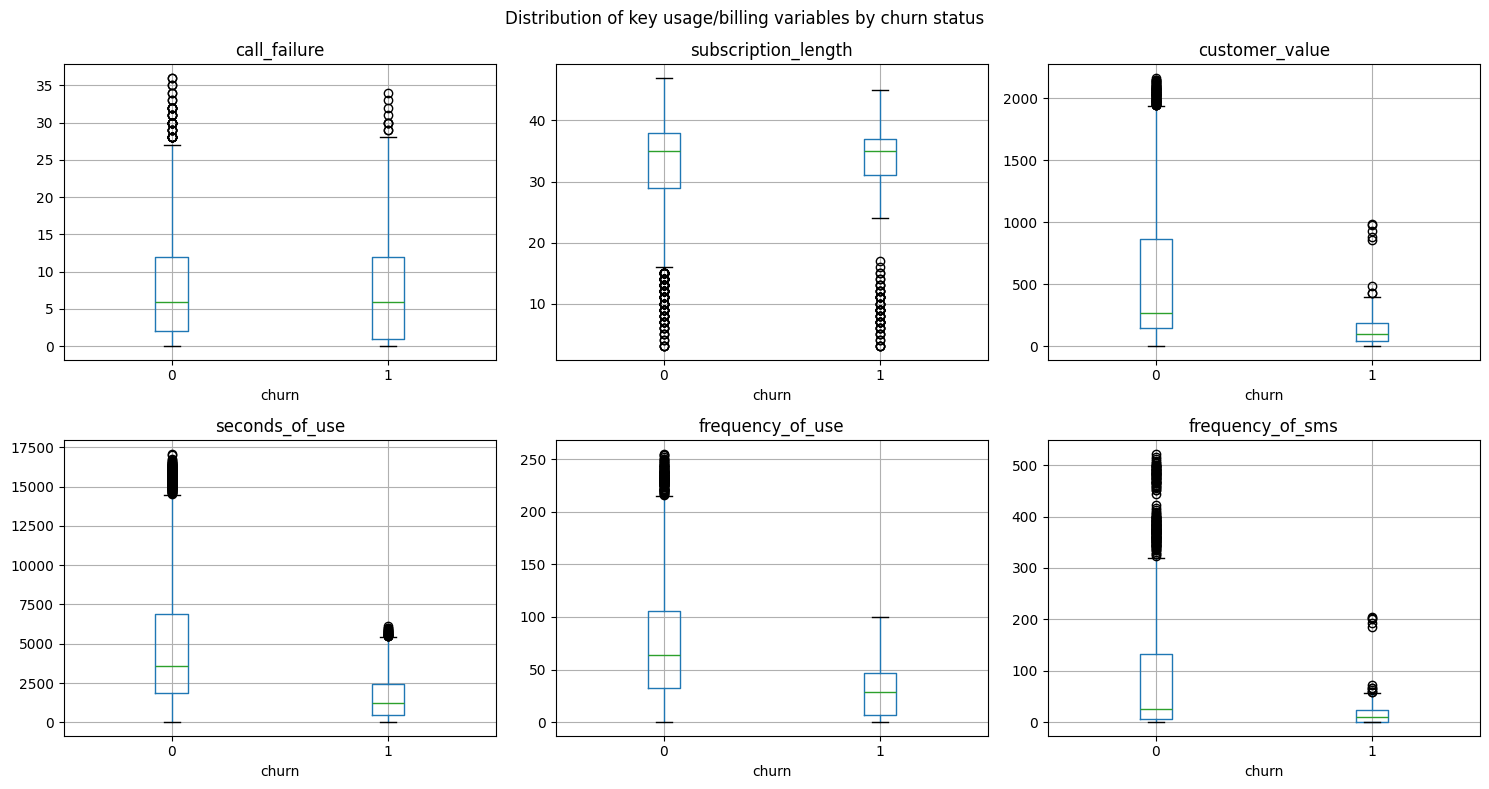


Mean value by churn status:
churn                          0            1
call_failure            7.792013     7.858744
subscription_length    32.595674    31.683857
customer_value        538.590759   132.175695
seconds_of_use       5069.588186  1648.661435
frequency_of_use       77.866473    30.697309
frequency_of_sms       84.353577    16.849776


In [4]:
continuous_vars = [
    "call_failure", "subscription_length", "customer_value",
    "seconds_of_use", "frequency_of_use", "frequency_of_sms",
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), continuous_vars):
    df.boxplot(column=col, by="churn", ax=ax)
    ax.set_title(col)
    ax.set_xlabel("churn")
plt.suptitle("Distribution of key usage/billing variables by churn status")
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "eda_boxplots.png", dpi=120, bbox_inches="tight")
plt.show()

print("\nMean value by churn status:")
print(df.groupby("churn")[continuous_vars].mean().T)

Correlation of each feature with churn:
churn                      1.000000
complains                  0.546055
status                     0.492867
is_dormant                 0.174288
call_failure               0.003310
age_group                 -0.005891
subscription_length       -0.037984
tariff_plan               -0.106000
charge_amount             -0.201662
frequency_of_sms          -0.218894
distinct_called_numbers   -0.270343
customer_value            -0.287078
seconds_of_use            -0.295999
frequency_of_use          -0.298608
Name: churn, dtype: float64


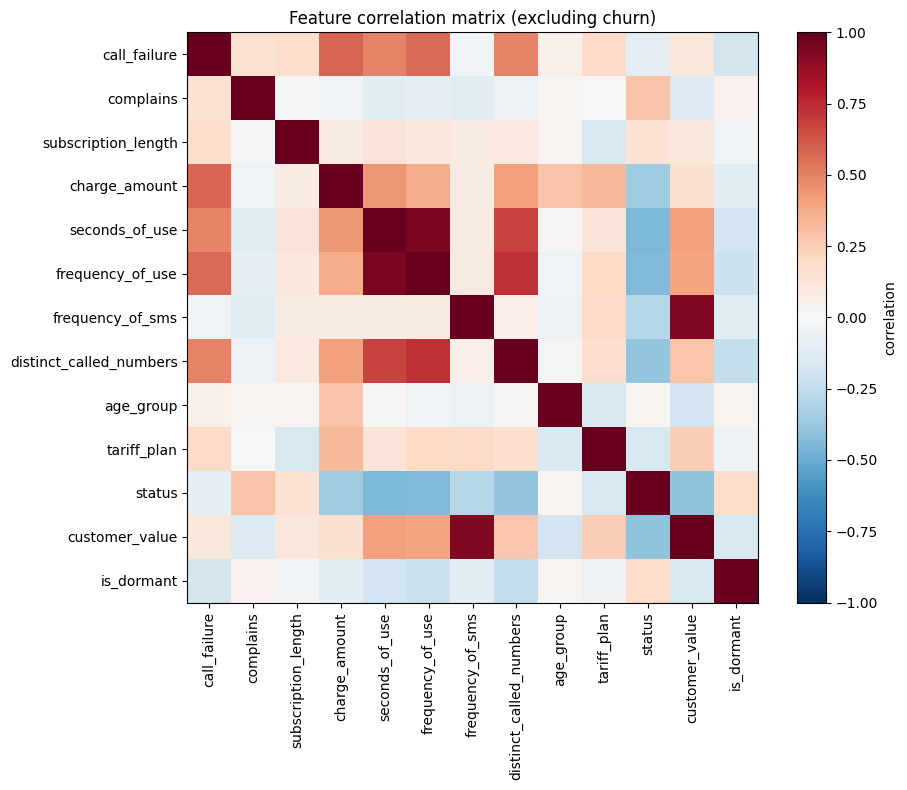


Notable collinearity: frequency_of_use vs seconds_of_use, r = 0.945


In [5]:
corr = df.corr(numeric_only=True)["churn"].sort_values(ascending=False)
print("Correlation of each feature with churn:")
print(corr)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(df.drop(columns=["churn"]).corr(numeric_only=True), cmap="RdBu_r", vmin=-1, vmax=1)
cols = df.drop(columns=["churn"]).columns
ax.set_xticks(range(len(cols)), cols, rotation=90)
ax.set_yticks(range(len(cols)), cols)
plt.colorbar(im, label="correlation")
plt.title("Feature correlation matrix (excluding churn)")
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "eda_correlation_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()

print("\nNotable collinearity: frequency_of_use vs seconds_of_use, r =",
      round(df["frequency_of_use"].corr(df["seconds_of_use"]), 3))

### A note on `status`

`status` (1 = active, 2 = non-active) is **not** in instruct.md's list of variables to analyze, and for good reason — it looks like leakage. See below: churn rate is 5% when `status=1` vs ~47% when `status=2`, by far the strongest relationship of any field in the dataset. If `status` reflects an account state that is set at/after the same time churn is determined, including it as a model feature would let the model "cheat" by reading the answer rather than predicting it.

**Decision: `status` is excluded from the model's feature set** (see Section 4), but kept in the cleaned CSV for reference/reporting.

In [6]:
print("Churn rate by status:")
print(df.groupby("status")["churn"].agg(["mean", "count"]).rename(columns={"mean": "churn_rate"}))

print("\nChurn rate for dormant vs active-usage customers:")
print(df.groupby("is_dormant")["churn"].agg(["mean", "count"]).rename(columns={"mean": "churn_rate"}))

Churn rate by status:
        churn_rate  count
status                   
1         0.055863   2166
2         0.475146    684

Churn rate for dormant vs active-usage customers:
            churn_rate  count
is_dormant                   
0             0.145389   2765
1             0.517647     85


## 4. Preprocessing

**Feature set**: every cleaned column except `churn` (target) and `status` (excluded per the leakage discussion above). `is_dormant` is kept — it's derived only from usage columns that are already legitimate features, not from the outcome, so it's a useful engineered flag rather than leakage.

**Encoding**: `complains`, `tariff_plan`, `is_dormant` are already binary; `age_group` and `charge_amount` are already meaningful ordinal integers — none need one-hot encoding.

**Scaling**: all features are standardized (mean 0, std 1). Tree models don't need this, but Logistic Regression does, and applying it uniformly keeps one preprocessing pipeline usable for every model.

**Split**: stratified 80/20 train/test split so the ~15.6% churn rate is preserved in both sets, given the class imbalance.

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

TARGET = "churn"
EXCLUDED = ["status"]  # leakage risk, see Section 3
FEATURES = [c for c in df.columns if c not in [TARGET] + EXCLUDED]

X = df[FEATURES].copy()
y = df[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

preprocessor = ColumnTransformer(
    transformers=[("scale", StandardScaler(), FEATURES)],
    remainder="drop",
)

print("Feature columns used for modeling:", FEATURES)
print(f"\nTrain: {X_train.shape}, churn rate {y_train.mean():.1%}")
print(f"Test:  {X_test.shape}, churn rate {y_test.mean():.1%}")

Feature columns used for modeling: ['call_failure', 'complains', 'subscription_length', 'charge_amount', 'seconds_of_use', 'frequency_of_use', 'frequency_of_sms', 'distinct_called_numbers', 'age_group', 'tariff_plan', 'customer_value', 'is_dormant']

Train: (2280, 12), churn rate 15.7%
Test:  (570, 12), churn rate 15.6%


## 5. Modeling

Baseline: Logistic Regression. Compared against Random Forest, XGBoost, and LightGBM, per instruct.md. All four handle the class imbalance (15.6% churn) via class weighting rather than resampling, to avoid synthesizing rows on top of an already small (~2,850-row) dataset.

Each model is wrapped in the same `preprocessor` from Section 4 and evaluated with 5-fold stratified cross-validation on the training set (small dataset → a single train/test split alone is noisy), then refit on the full training set for the held-out test evaluation in Section 6.

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / pos

models = {
    "Logistic Regression": LogisticRegression(
        class_weight="balanced", max_iter=1000, random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300, scale_pos_weight=scale_pos_weight, eval_metric="logloss",
        random_state=42, n_jobs=-1,
    ),
    # n_jobs=1: LightGBM's own multithreading crashes (Windows access-violation)
    # when combined with sklearn's cross_validate on this environment.
    "LightGBM": LGBMClassifier(
        n_estimators=300, is_unbalance=True, random_state=42, n_jobs=1, verbosity=-1,
    ),
}

pipelines = {
    name: Pipeline([("preprocess", preprocessor), ("model", model)])
    for name, model in models.items()
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ["precision", "recall", "f1", "roc_auc"]

cv_results = {}
for name, pipe in pipelines.items():
    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring)
    cv_results[name] = {m: scores[f"test_{m}"].mean() for m in scoring}
    cv_results[name].update({f"{m}_std": scores[f"test_{m}"].std() for m in scoring})

cv_df = pd.DataFrame(cv_results).T
print("5-fold stratified CV results (mean over folds):")
cv_df[["precision", "recall", "f1", "roc_auc"]].round(3)

5-fold stratified CV results (mean over folds):


,precision,recall,f1,roc_auc
Logistic Regression,0.469,0.854,0.605,0.929
Random Forest,0.882,0.697,0.778,0.977
XGBoost,0.832,0.851,0.841,0.978
LightGBM,0.867,0.835,0.850,0.983


## 6. Evaluation on the held-out test set

The 5-fold CV numbers above are useful for comparing models on the training data, but the number instruct.md actually asks for — Precision, Recall, F1, ROC-AUC, and a Confusion Matrix — should be reported on data the model never touched during training or CV. Each pipeline is refit on the full training set and scored once on `X_test`/`y_test`.

In [9]:
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix,
)

test_results = {}
fitted_pipelines = {}
test_probas = {}

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    fitted_pipelines[name] = pipe
    proba = pipe.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)
    test_probas[name] = proba

    test_results[name] = {
        "precision": precision_score(y_test, pred),
        "recall": recall_score(y_test, pred),
        "f1": f1_score(y_test, pred),
        "roc_auc": roc_auc_score(y_test, proba),
    }

results_df = pd.DataFrame(test_results).T.round(3)
results_df.to_csv(OUTPUTS_DIR / "model_comparison.csv")
print("Held-out test set performance (threshold = 0.5):")
results_df

Held-out test set performance (threshold = 0.5):


,precision,recall,f1,roc_auc
Logistic Regression,0.438,0.865,0.581,0.914
Random Forest,0.904,0.742,0.815,0.981
XGBoost,0.874,0.854,0.864,0.981
LightGBM,0.884,0.854,0.869,0.986


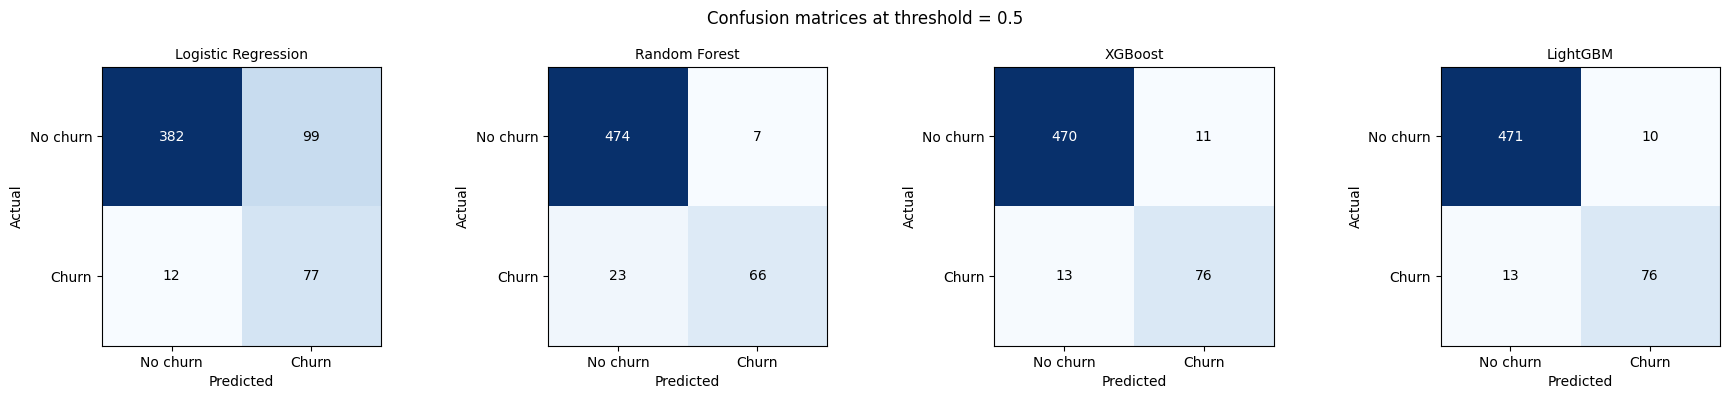

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, name in zip(axes, pipelines.keys()):
    pred = (test_probas[name] >= 0.5).astype(int)
    cm = confusion_matrix(y_test, pred)
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticks([0, 1], ["No churn", "Churn"])
    ax.set_yticks([0, 1], ["No churn", "Churn"])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                     color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.suptitle("Confusion matrices at threshold = 0.5")
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "confusion_matrices.png", dpi=120, bbox_inches="tight")
plt.show()

In [11]:
best_model_name = results_df["roc_auc"].idxmax()
best_pipeline = fitted_pipelines[best_model_name]

print(f"Best model by ROC-AUC: {best_model_name}")
print(results_df.loc[best_model_name])
print(
    "\nModel selection rationale: ROC-AUC is used to pick the best model because it "
    "summarizes ranking quality across all thresholds, which matters here since "
    "Section 7 chooses the operating threshold from business costs rather than "
    "defaulting to 0.5. Precision/Recall at the default 0.5 threshold (shown above) "
    "would be a premature basis for model choice -- a model with slightly lower "
    "ROC-AUC but a 'lucky' 0.5 threshold isn't actually better once the threshold "
    "itself becomes a tunable business decision."
)

Best model by ROC-AUC: LightGBM
precision    0.884
recall       0.854
f1           0.869
roc_auc      0.986
Name: LightGBM, dtype: float64

Model selection rationale: ROC-AUC is used to pick the best model because it summarizes ranking quality across all thresholds, which matters here since Section 7 chooses the operating threshold from business costs rather than defaulting to 0.5. Precision/Recall at the default 0.5 threshold (shown above) would be a premature basis for model choice -- a model with slightly lower ROC-AUC but a 'lucky' 0.5 threshold isn't actually better once the threshold itself becomes a tunable business decision.


## 7. Threshold selection — the "Important Consideration" from instruct.md

The two error types have very different, and very unequal, costs:

- **False Positive** (predicted churn, customer actually stays): wasted retention-campaign spend on a customer who was never leaving. Modeled as a flat assumed cost per contacted customer — **this is a placeholder assumption, not a real campaign cost**, and should be replaced with the business's actual outreach cost per customer.
- **False Negative** (predicted stay, customer actually churns): the business loses that customer's revenue. Modeled as that customer's actual `customer_value` — a real number already in the data, not an assumption.

Because FN cost scales with the individual customer's value while FP cost is flat, the optimal threshold isn't 0.5 — it should tilt toward catching high-value churners even at the cost of more false alarms. We sweep thresholds on the best model's test-set probabilities and pick the one that minimizes total expected cost.

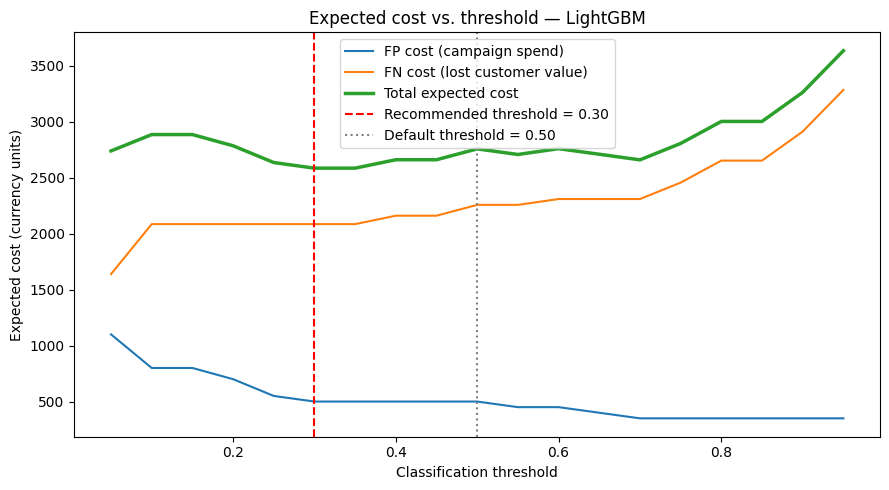

Recommended threshold: 0.30

                threshold  fp_count  fn_count  fp_cost  fn_cost  total_cost
default (0.50)        0.5        10        13      500  2257.12     2757.12
recommended           0.3        10        11      500  2085.08     2585.08


In [12]:
# ADJUSTABLE ASSUMPTION -- replace with the business's real per-customer
# retention outreach cost. This placeholder is deliberately small relative
# to typical customer_value so the sweep isn't dominated by an arbitrary
# guess, but it is still just a guess.
FP_COST = 50

customer_value_test = df.loc[X_test.index, "customer_value"]
best_proba = test_probas[best_model_name]

thresholds = np.linspace(0.05, 0.95, 19)
sweep = []
for t in thresholds:
    pred = (best_proba >= t).astype(int)
    fp_mask = (pred == 1) & (y_test.values == 0)
    fn_mask = (pred == 0) & (y_test.values == 1)
    fp_cost = fp_mask.sum() * FP_COST
    fn_cost = customer_value_test.values[fn_mask].sum()
    sweep.append({
        "threshold": t, "fp_count": fp_mask.sum(), "fn_count": fn_mask.sum(),
        "fp_cost": fp_cost, "fn_cost": fn_cost, "total_cost": fp_cost + fn_cost,
    })

sweep_df = pd.DataFrame(sweep)
sweep_df.to_csv(OUTPUTS_DIR / "threshold_sweep.csv", index=False)
best_row = sweep_df.loc[sweep_df["total_cost"].idxmin()]
recommended_threshold = best_row["threshold"]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(sweep_df["threshold"], sweep_df["fp_cost"], label="FP cost (campaign spend)")
ax.plot(sweep_df["threshold"], sweep_df["fn_cost"], label="FN cost (lost customer value)")
ax.plot(sweep_df["threshold"], sweep_df["total_cost"], label="Total expected cost", linewidth=2.5)
ax.axvline(recommended_threshold, color="red", linestyle="--",
           label=f"Recommended threshold = {recommended_threshold:.2f}")
ax.axvline(0.5, color="gray", linestyle=":", label="Default threshold = 0.50")
ax.set_xlabel("Classification threshold")
ax.set_ylabel("Expected cost (currency units)")
ax.set_title(f"Expected cost vs. threshold — {best_model_name}")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "threshold_cost_curve.png", dpi=120, bbox_inches="tight")
plt.show()

# nearest-row lookup instead of exact float equality, since 0.5 may not be
# bit-exact in the linspace grid
default_idx = (sweep_df["threshold"] - 0.5).abs().idxmin()
comparison = sweep_df.loc[[default_idx, sweep_df["total_cost"].idxmin()]].copy()
comparison.index = ["default (0.50)", "recommended"]
print(f"Recommended threshold: {recommended_threshold:.2f}\n")
print(comparison)

## 8. Risk scoring

`Risk Score = Churn Probability × Customer Value`, per instruct.md — this ranks customers by *financial impact of losing them*, not just by how likely they are to churn, so retention effort goes to valuable at-risk customers first.

For this section the best model type is refit on the **full** cleaned dataset (not just the training split) — this is the "deployment" pass meant to score every current customer, including the ones held out for testing above. Predictions on rows the model was trained on are optimistic, which is an accepted limitation of scoring your own customer base with an in-sample model; it doesn't affect the test-set metrics already reported in Section 6.

The 85 dormant customers (`customer_value` = 0) are handled separately: their Risk Score is always 0 regardless of churn probability, which would silently hide them from a single ranked list even though some have a high probability of churning. They get their own watchlist, ranked by churn probability alone.

In [13]:
from sklearn.base import clone

# Refit the winning model type on the full dataset for deployment-style scoring
deployment_pipeline = clone(best_pipeline)
deployment_pipeline.fit(X, y)

risk_df = df.copy()
# The source data has no customer ID column at all -- a ranked list is not
# actionable without one, so assign a stable synthetic ID from the cleaned
# dataframe's row position before any sorting happens.
risk_df.insert(0, "customer_id", [f"CUST-{i:05d}" for i in risk_df.index])

risk_df["churn_probability"] = deployment_pipeline.predict_proba(X)[:, 1]
risk_df["predicted_churn"] = (risk_df["churn_probability"] >= recommended_threshold).astype(int)
risk_df["risk_score"] = risk_df["churn_probability"] * risk_df["customer_value"]

active_customers = risk_df[risk_df["is_dormant"] == 0].sort_values("risk_score", ascending=False)
dormant_watchlist = risk_df[risk_df["is_dormant"] == 1].sort_values("churn_probability", ascending=False)

active_customers.to_csv(OUTPUTS_DIR / "high_risk_customers.csv", index=False)
dormant_watchlist.to_csv(OUTPUTS_DIR / "dormant_watchlist.csv", index=False)

print(f"Ranked {len(active_customers)} active customers -> outputs/high_risk_customers.csv")
print(f"Flagged {len(dormant_watchlist)} dormant customers separately -> outputs/dormant_watchlist.csv")
print(f"\nTop 10 highest-risk active customers (threshold={recommended_threshold:.2f}):")
active_customers[["customer_id", "churn_probability", "predicted_churn", "customer_value", "risk_score"]].head(10)

Ranked 2765 active customers -> outputs/high_risk_customers.csv
Flagged 85 dormant customers separately -> outputs/dormant_watchlist.csv

Top 10 highest-risk active customers (threshold=0.30):


,customer_id,churn_probability,predicted_churn,customer_value,risk_score
388,CUST-00388,0.999869,1,987.255,987.125746
686,CUST-00686,0.999920,1,978.390,978.312107
954,CUST-00954,0.999811,1,929.295,929.119220
997,CUST-00997,0.999649,1,883.800,883.489645
834,CUST-00834,0.999865,1,858.280,858.163794
1522,CUST-01522,0.999988,1,487.170,487.164140
672,CUST-00672,0.999971,1,432.315,432.302376
174,CUST-00174,0.999861,1,431.910,431.849783
1328,CUST-01328,0.999968,1,395.685,395.672429
2664,CUST-02664,0.999926,1,392.445,392.415937


## 9. Feature importance

Logistic Regression coefficients (on standardized features, so magnitudes are comparable to each other) show *direction* as well as strength. Tree-model importances (Random Forest / XGBoost / LightGBM gain-based) show strength only. Comparing both guards against over-trusting a single model's idea of what matters — and lets us sanity-check that `status` staying excluded didn't just get replaced by something equally leaky (`complains` ranking highest is expected and legitimate: it's a real, pre-churn customer signal, not an outcome label like `status` was).

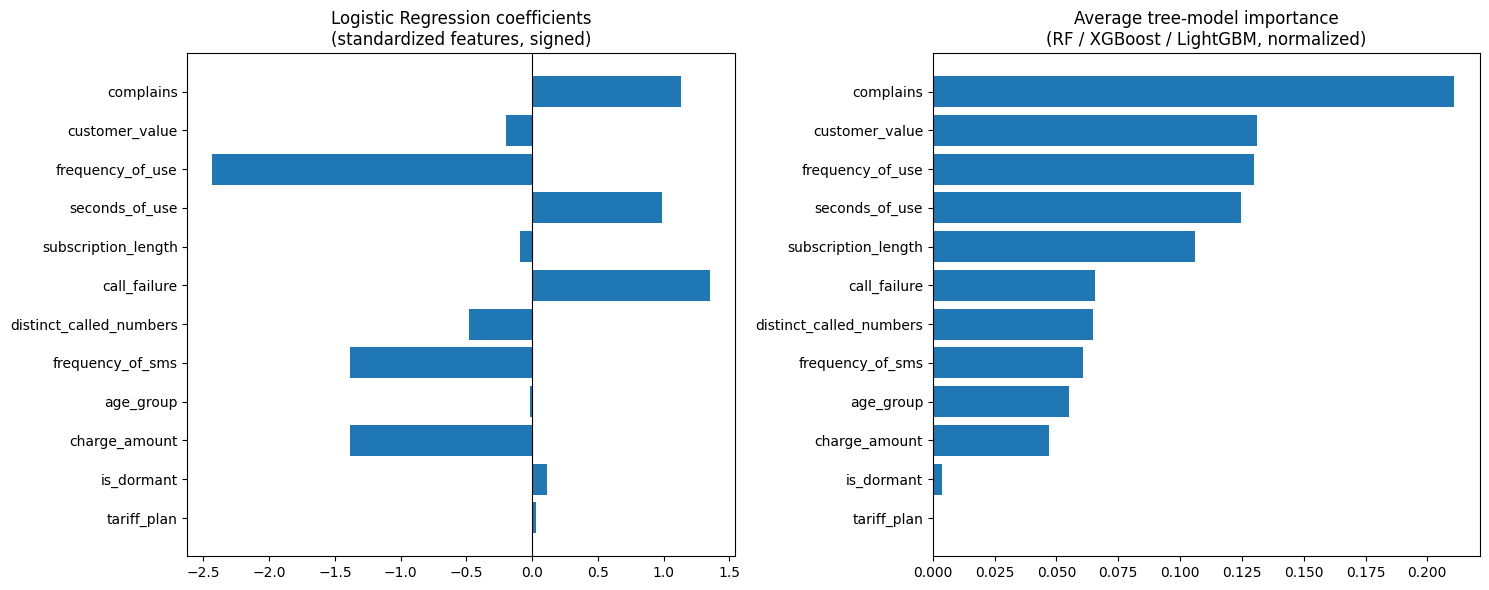

,feature,logreg_coefficient,random_forest_importance,xgboost_importance,lightgbm_importance,avg_tree_importance
0,complains,1.136720,0.136960,0.479481,143,0.210777
1,customer_value,-0.198337,0.157316,0.119664,1052,0.131290
2,frequency_of_use,-2.432605,0.153952,0.074448,1449,0.129800
3,seconds_of_use,0.986949,0.140830,0.071711,1456,0.124773
4,subscription_length,-0.092524,0.095952,0.027603,1752,0.106074
5,call_failure,1.351663,0.055026,0.048509,835,0.065437
6,distinct_called_numbers,-0.478022,0.076702,0.029049,793,0.064621
7,frequency_of_sms,-1.383218,0.088813,0.021445,652,0.060901
8,age_group,-0.013609,0.056309,0.030425,711,0.055245
9,charge_amount,-1.382230,0.033657,0.093171,126,0.046943


In [14]:
importance_df = pd.DataFrame({"feature": FEATURES})
importance_df["logreg_coefficient"] = fitted_pipelines["Logistic Regression"].named_steps["model"].coef_[0]

for name in ["Random Forest", "XGBoost", "LightGBM"]:
    col = f"{name.lower().replace(' ', '_')}_importance"
    importance_df[col] = fitted_pipelines[name].named_steps["model"].feature_importances_

# rank features by mean normalized tree importance for a single sort order
tree_cols = [c for c in importance_df.columns if c.endswith("_importance")]
norm = importance_df[tree_cols] / importance_df[tree_cols].sum()
importance_df["avg_tree_importance"] = norm.mean(axis=1)
importance_df = importance_df.sort_values("avg_tree_importance", ascending=False).reset_index(drop=True)
importance_df.to_csv(OUTPUTS_DIR / "feature_importance.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
order = importance_df["feature"]

axes[0].barh(order, importance_df.set_index("feature").loc[order, "logreg_coefficient"])
axes[0].set_title("Logistic Regression coefficients\n(standardized features, signed)")
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].invert_yaxis()

axes[1].barh(order, importance_df.set_index("feature").loc[order, "avg_tree_importance"])
axes[1].set_title("Average tree-model importance\n(RF / XGBoost / LightGBM, normalized)")
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "feature_importance.png", dpi=120, bbox_inches="tight")
plt.show()

importance_df

## 10. Business analysis & retention recommendations

Pulling together the financial impact, the threshold decision, and the retention actions the churn drivers point to.

In [15]:
total_portfolio_value = risk_df["customer_value"].sum()
actual_churned_value = risk_df.loc[risk_df["churn"] == 1, "customer_value"].sum()
predicted_at_risk_value = active_customers.loc[active_customers["predicted_churn"] == 1, "customer_value"].sum()

n_flagged = (risk_df["predicted_churn"] == 1).sum()

print("=== Financial impact ===")
print(f"Total portfolio value (sum of customer_value, all {len(risk_df)} customers): {total_portfolio_value:,.0f}")
print(f"Value already lost to observed churn in this dataset: {actual_churned_value:,.0f} "
      f"({actual_churned_value/total_portfolio_value:.1%} of portfolio)")
print(f"Value flagged as at-risk by the model at threshold {recommended_threshold:.2f} "
      f"({n_flagged} customers): {predicted_at_risk_value:,.0f} "
      f"({predicted_at_risk_value/total_portfolio_value:.1%} of portfolio)")

print(f"\n=== Threshold recommendation ===")
print(f"Recommended operating threshold: {recommended_threshold:.2f} (default would be 0.50)")
print(
    "Lowering the threshold below 0.50 trades additional false positives (wasted "
    f"outreach, assumed {FP_COST} currency units each) for fewer false negatives "
    "(lost customer_value, which is usually far larger than the outreach cost for "
    "this dataset's higher-value customers). Section 7's cost sweep shows this "
    "trade-off is worth making here -- but FP_COST is a placeholder, so this "
    "threshold should be re-derived once real campaign-cost figures are available."
)

=== Financial impact ===
Total portfolio value (sum of customer_value, all 2850 customers): 1,353,723
Value already lost to observed churn in this dataset: 58,950 (4.4% of portfolio)
Value flagged as at-risk by the model at threshold 0.30 (468 customers): 59,109 (4.4% of portfolio)

=== Threshold recommendation ===
Recommended operating threshold: 0.30 (default would be 0.50)
Lowering the threshold below 0.50 trades additional false positives (wasted outreach, assumed 50 currency units each) for fewer false negatives (lost customer_value, which is usually far larger than the outreach cost for this dataset's higher-value customers). Section 7's cost sweep shows this trade-off is worth making here -- but FP_COST is a placeholder, so this threshold should be re-derived once real campaign-cost figures are available.


In [16]:
top_drivers = importance_df.head(5)["feature"].tolist()
print("Top 5 churn drivers by average tree-model importance:", top_drivers)

print("""
=== Retention recommendations, tied to the drivers above ===

1. complains -- the single strongest legitimate driver (83% churn rate for
   customers who have filed a complaint, vs 10% for those who haven't).
   Route any open complaint into a retention workflow automatically, rather
   than treating complaint-handling and churn-prevention as separate processes.

2. customer_value / frequency_of_use / seconds_of_use -- churned customers
   have visibly lower usage and value than retained ones (Section 3 boxplots).
   Declining usage is a leading indicator, not just a correlate -- a
   month-over-month drop for an individual customer is worth flagging even
   before churn probability crosses the model's threshold.

3. subscription_length -- a weaker driver on its own, but worth combining
   with tenure-based offers: newer customers with early complaints or usage
   drops are a materially different retention case than long-tenured ones.

4. Dormant customers (customer_value = 0, 52% churn rate) fall outside the
   Risk Score ranking entirely, since the score is 0 regardless of churn
   probability. They should be worked as a separate list
   (outputs/dormant_watchlist.csv) -- likely a win-back/reactivation offer
   rather than a standard retention offer, since they aren't currently
   generating value to protect.

5. Operationally: contact the ranked list in outputs/high_risk_customers.csv
   top-down -- it is already sorted by financial impact (risk_score), so the
   ordering itself is the prioritization.
""")

Top 5 churn drivers by average tree-model importance: ['complains', 'customer_value', 'frequency_of_use', 'seconds_of_use', 'subscription_length']

=== Retention recommendations, tied to the drivers above ===

1. complains -- the single strongest legitimate driver (83% churn rate for
   customers who have filed a complaint, vs 10% for those who haven't).
   Route any open complaint into a retention workflow automatically, rather
   than treating complaint-handling and churn-prevention as separate processes.

2. customer_value / frequency_of_use / seconds_of_use -- churned customers
   have visibly lower usage and value than retained ones (Section 3 boxplots).
   Declining usage is a leading indicator, not just a correlate -- a
   month-over-month drop for an individual customer is worth flagging even
   before churn probability crosses the model's threshold.

3. subscription_length -- a weaker driver on its own, but worth combining
   with tenure-based offers: newer customers with earl

## 11. Save the final pipeline

Persists the fitted preprocessing + model pipeline (`deployment_pipeline`, trained on the full cleaned dataset in Section 8) plus the metadata needed to use it correctly later: which features it expects, in what order, and the recommended threshold. Without this, `models/best_model_pipeline.joblib` alone would be a black box someone could accidentally call with the wrong columns or a default 0.5 threshold that ignores the cost analysis in Section 7.

In [17]:
import joblib
import json
from datetime import datetime, timezone

MODEL_PATH = MODELS_DIR / "best_model_pipeline.joblib"
METADATA_PATH = MODELS_DIR / "model_metadata.json"

joblib.dump(deployment_pipeline, MODEL_PATH)

metadata = {
    "model_type": best_model_name,
    "features_in_order": FEATURES,
    "excluded_features": EXCLUDED,
    "target": TARGET,
    "recommended_threshold": float(recommended_threshold),
    "default_threshold_note": "0.5 is NOT recommended -- see Section 7 for the cost-based derivation",
    "fp_cost_assumption": FP_COST,
    "test_set_metrics_at_0.5": results_df.loc[best_model_name].to_dict(),
    "trained_on_rows": len(df),
    "saved_at_utc": datetime.now(timezone.utc).isoformat(),
}
with open(METADATA_PATH, "w") as f:
    json.dump(metadata, f, indent=2)

print(f"Saved pipeline -> {MODEL_PATH}")
print(f"Saved metadata -> {METADATA_PATH}")
print(json.dumps(metadata, indent=2))

Saved pipeline -> models\best_model_pipeline.joblib
Saved metadata -> models\model_metadata.json
{
  "model_type": "LightGBM",
  "features_in_order": [
    "call_failure",
    "complains",
    "subscription_length",
    "charge_amount",
    "seconds_of_use",
    "frequency_of_use",
    "frequency_of_sms",
    "distinct_called_numbers",
    "age_group",
    "tariff_plan",
    "customer_value",
    "is_dormant"
  ],
  "excluded_features": [
    "status"
  ],
  "target": "churn",
  "recommended_threshold": 0.3,
  "default_threshold_note": "0.5 is NOT recommended -- see Section 7 for the cost-based derivation",
  "fp_cost_assumption": 50,
  "test_set_metrics_at_0.5": {
    "precision": 0.884,
    "recall": 0.854,
    "f1": 0.869,
    "roc_auc": 0.986
  },
  "trained_on_rows": 2850,
  "saved_at_utc": "2026-08-12T13:37:55.335403+00:00"
}
